Day1 : Dataset Understanding

In [3]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [1]:
pip install tensorflow[and-cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 75.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalli

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2



In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brian-tumor-dataset' dataset.
Path to dataset files: /kaggle/input/brian-tumor-dataset


In [5]:
print(os.listdir(path))

['metadata_rgb_only.csv', 'Brain Tumor Data Set', 'metadata.csv']


In [6]:
path1=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set")
print(os.listdir(path1))

['Brain Tumor', 'Healthy']


In [7]:
images_path=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Brain Tumor")
print(images_path)

/kaggle/input/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor


In [8]:
print(len(os.listdir(images_path)))
print(os.listdir(images_path)[:5])

2513
['Cancer (489).jpg', 'Cancer (72).tif', 'Cancer (2411).jpg', 'Cancer (1065).jpg', 'Cancer (1014).jpg']


In [9]:
import pandas as pd
import os

data = []

folder_name = "Brain Tumor"
count = len(os.listdir(images_path))

data.append((folder_name, count))

print(f"{folder_name}: {count} images")

df = pd.DataFrame(data, columns=["Class", "Count"])
df

Brain Tumor: 2513 images


,Class,Count
0,Brain Tumor,2513


In [10]:
images_pathhealthy=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Healthy")
print(images_pathhealthy)

/kaggle/input/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Healthy


In [11]:
print(len(os.listdir(images_pathhealthy)))
print(os.listdir(images_pathhealthy)[:5])

2087
['Not Cancer  (446).jpg', 'Not Cancer  (1646).jpg', 'Not Cancer  (1548).jpg', 'Not Cancer  (1864).jpg', 'Not Cancer  (1736).jpg']


In [12]:
import pandas as pd
import os

data = []

# Brain Tumor
tumor_images = [img for img in os.listdir(images_path) if img.endswith(('.jpg', '.png', '.tif'))]
tumor_count = len(tumor_images)
data.append(("Brain Tumor", tumor_count))

print(f"Brain Tumor: {tumor_count} images")

# Healthy
healthy_images = [img for img in os.listdir(images_pathhealthy) if img.endswith(('.jpg', '.png', '.tif'))]
healthy_count = len(healthy_images)
data.append(("Healthy", healthy_count))

print(f"Healthy: {healthy_count} images")


# Create DataFrame
df = pd.DataFrame(data, columns=["Class", "Count"])

df

Brain Tumor: 2445 images
Healthy: 2075 images


,Class,Count
0,Brain Tumor,2445
1,Healthy,2075


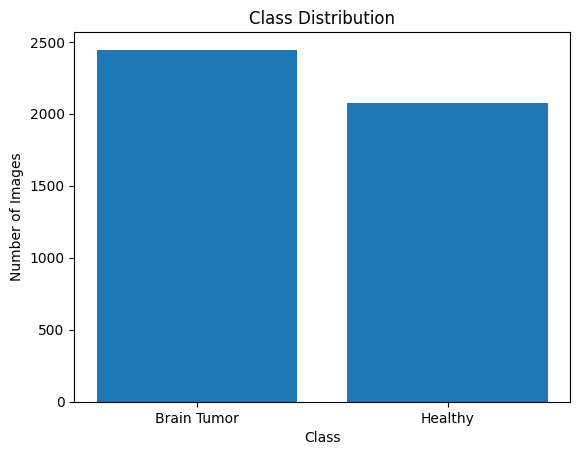

In [13]:
plt.bar(df["Class"], df["Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
from PIL import Image
import os

sizes = []

# Brain Tumor images
for img_name in os.listdir(images_path)[:50]:  # sample
    img_path = os.path.join(images_path, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

# Healthy images
for img_name in os.listdir(images_pathhealthy)[:50]:  # sample
    img_path = os.path.join(images_pathhealthy, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

print("Sample Image Sizes:", sizes[:10])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load one sample image
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))

print("Min pixel value:", img.min())
print("Max pixel value:", img.max())
print("Mean brightness:", img.mean())

In [ ]:
brightness_values = []

for img_name in os.listdir(images_path)[:50]:
    img = plt.imread(os.path.join(images_path, img_name))
    brightness_values.append(img.mean())

print("Average brightness:", sum(brightness_values)/len(brightness_values))

In [ ]:
plt.hist(brightness_values, bins=20)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

In [ ]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.hist(widths, bins=20, alpha=0.5, label='Width')
plt.hist(heights, bins=20, alpha=0.5, label='Height')
plt.legend()
plt.title("Image Size Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import hashlib

hashes = set()
duplicates = 0

for img_name in os.listdir(images_path)[:100]:
    with open(os.path.join(images_path, img_name), 'rb') as f:
        filehash = hashlib.md5(f.read()).hexdigest()
        if filehash in hashes:
            duplicates += 1
        else:
            hashes.add(filehash)

print("Duplicate images:", duplicates)

In [ ]:
df["Percentage"] = (df["Count"] / df["Count"].sum()) * 100
df

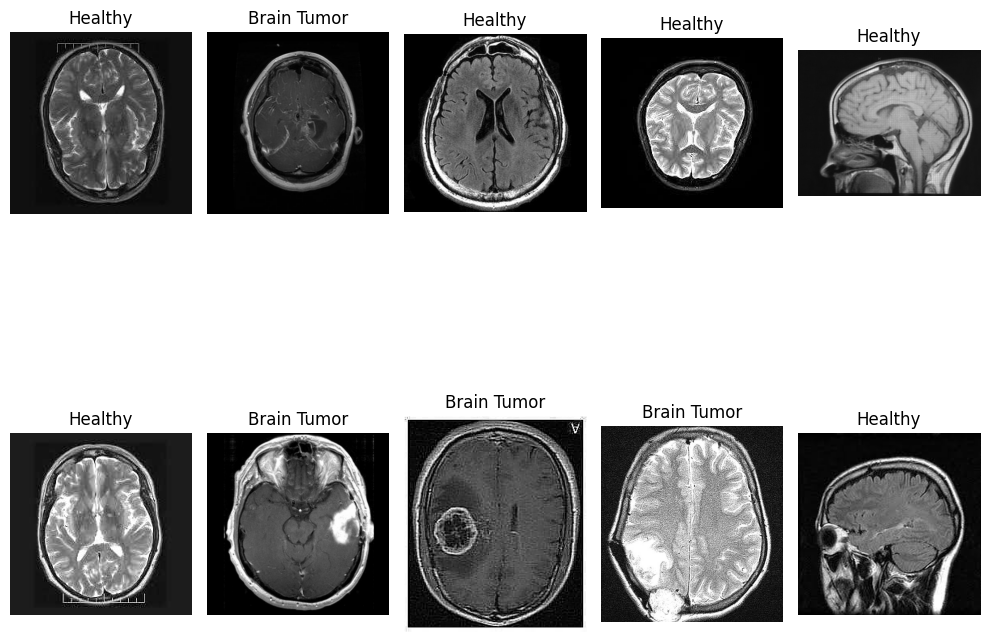

In [14]:
import matplotlib.pyplot as plt
import random
import os

plt.figure(figsize=(10, 10))

for i in range(10):

    # Randomly choose class
    if random.random() > 0.5:
        folder = "Brain Tumor"
        folder_path = images_path
    else:
        folder = "Healthy"
        folder_path = images_pathhealthy

    # Pick random image
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = plt.imread(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image mode:", img.mode)

In [ ]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image mode:", img.mode)

In [ ]:
from PIL import Image

corrupted = 0

for img_name in os.listdir(images_path):
    try:
        img = Image.open(os.path.join(images_path, img_name))
    except:
        corrupted += 1

print("Corrupted images:", corrupted)

In [ ]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image shape:", img.shape)

In [ ]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image shape:", img.shape)

In [ ]:
plt.pie(df["Count"], labels=df["Class"], autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

In [ ]:
tumor_pixels = []
healthy_pixels = []

# Tumor
for img_name in os.listdir(images_path)[:20]:
    img = plt.imread(os.path.join(images_path, img_name))
    tumor_pixels.extend(img.flatten())

# Healthy
for img_name in os.listdir(images_pathhealthy)[:20]:
    img = plt.imread(os.path.join(images_pathhealthy, img_name))
    healthy_pixels.extend(img.flatten())

# Plot
plt.hist(tumor_pixels, bins=50, alpha=0.5, label='Tumor')
plt.hist(healthy_pixels, bins=50, alpha=0.5, label='Healthy')
plt.legend()
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
label_map = {
    "Healthy": 0,
    "Brain Tumor": 1
}

print(label_map)

In [ ]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Min pixel:", img.min())
print("Max pixel:", img.max())

In [ ]:
import cv2

img_path = os.path.join(images_path, os.listdir(images_path)[0])
img = cv2.imread(img_path, 0)

edges = cv2.Canny(img, 100, 200)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.show()

In [ ]:
tumor_mean = []
healthy_mean = []

for img_name in os.listdir(images_path)[:20]:
    img = plt.imread(os.path.join(images_path, img_name))
    tumor_mean.append(img.mean())

for img_name in os.listdir(images_pathhealthy)[:20]:
    img = plt.imread(os.path.join(images_pathhealthy, img_name))
    healthy_mean.append(img.mean())

plt.boxplot([tumor_mean, healthy_mean], labels=["Tumor", "Healthy"])
plt.title("Brightness Comparison")
plt.show()


In [ ]:
import numpy as np
import cv2

def average_image(folder_path):
    images = []

    for img_name in os.listdir(folder_path)[:50]:
        img = cv2.imread(os.path.join(folder_path, img_name), 0)
        img = cv2.resize(img, (224, 224))
        images.append(img)

    return np.mean(images, axis=0)

tumor_avg = average_image(images_path)
healthy_avg = average_image(images_pathhealthy)

plt.subplot(1,2,1)
plt.imshow(tumor_avg, cmap='gray')
plt.title("Average Tumor Image")

plt.subplot(1,2,2)
plt.imshow(healthy_avg, cmap='gray')
plt.title("Average Healthy Image")

plt.show()

In [ ]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
plt.imshow(img, cmap='hot')
plt.colorbar()
plt.title("Heatmap Representation")
plt.axis('off')

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2
import random

plt.figure(figsize=(10, 10))

# Tumor images
for i in range(5):
    img_name = random.choice(os.listdir(images_path))
    img = cv2.imread(os.path.join(images_path, img_name), 0)

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='hot')
    plt.title("Tumor")
    plt.axis('off')

# Healthy images
for i in range(5):
    img_name = random.choice(os.listdir(images_pathhealthy))
    img = cv2.imread(os.path.join(images_pathhealthy, img_name), 0)

    plt.subplot(2, 5, i+6)
    plt.imshow(img, cmap='hot')
    plt.title("Healthy")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2

def avg_heatmap(folder):
    imgs = []

    for img_name in os.listdir(folder)[:50]:
        img = cv2.imread(os.path.join(folder, img_name), 0)
        img = cv2.resize(img, (224, 224))
        imgs.append(img)

    return np.mean(imgs, axis=0)

tumor_avg = avg_heatmap(images_path)
healthy_avg = avg_heatmap(images_pathhealthy)

plt.subplot(1,2,1)
plt.imshow(tumor_avg, cmap='hot')
plt.title("Tumor Heatmap")

plt.subplot(1,2,2)
plt.imshow(healthy_avg, cmap='hot')
plt.title("Healthy Heatmap")

plt.colorbar()
plt.show()

In [ ]:
diff = tumor_avg - healthy_avg

plt.imshow(diff, cmap='hot')
plt.colorbar()
plt.title("Difference Heatmap (Tumor - Healthy)")
plt.axis('off')
plt.show()

In [ ]:
img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

img_norm = img / 255.0

plt.imshow(img_norm, cmap='hot')
plt.colorbar()
plt.title("Normalized Heatmap")
plt.axis('off')
plt.show()

In [ ]:
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0)
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1)

gradient = np.sqrt(grad_x**2 + grad_y**2)

plt.imshow(gradient, cmap='hot')
plt.colorbar()
plt.title("Gradient Heatmap")
plt.axis('off')
plt.show()

In [ ]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[1]))

plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Histogram (Single Image)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import cv2

img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

plt.imshow(laplacian, cmap='gray')
plt.title("Sharpness (Edges/Texture)")
plt.show()

In [ ]:
import cv2

img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

# Increase contrast
contrast = cv2.equalizeHist(img)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Enhanced")

plt.show()

DAY 2 : Data Cleaning & Preprocessing

In [15]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from collections import Counter

In [16]:
CONFIG = {
    "IMG_SIZE": 224,
    "TUMOR_LABEL": 1,
    "HEALTHY_LABEL": 0
}

# 👉 UPDATE THESE PATHS
tumor_path = images_path
healthy_path = images_pathhealthy

In [17]:


def process_images(folder_path, label):
    data = []
    labels = []
    count = 0

    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path, 0)

            if img is None:
                continue

            # Resize
            img = cv2.resize(img, (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))

            # Normalize
            img = img.astype("float32") / 255.0

            data.append(img)
            labels.append(label)

            count += 1

        except Exception as e:
            print(f"Error processing {img_name}")

    return data, labels, count

In [18]:

print("Processing Tumor Images...")
tumor_data, tumor_labels, tumor_count = process_images(
    tumor_path, CONFIG["TUMOR_LABEL"]
)

print("Processing Healthy Images...")
healthy_data, healthy_labels, healthy_count = process_images(
    healthy_path, CONFIG["HEALTHY_LABEL"]
)

# Combine
data = tumor_data + healthy_data
labels = tumor_labels + healthy_labels

print(f"Tumor count: {tumor_count}")
print(f"Healthy count: {healthy_count}")


Processing Tumor Images...
Processing Healthy Images...
Tumor count: 2513
Healthy count: 2087


In [19]:
class_counts = Counter(labels)
print("Class Distribution:", class_counts)

Class Distribution: Counter({1: 2513, 0: 2087})


In [20]:
X = np.array(data)
y = np.array(labels)

print("Shape before reshape:", X.shape)

Shape before reshape: (4600, 224, 224)


In [21]:
X = X.reshape(-1, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"], 1)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (4600, 224, 224, 1)
Final y shape: (4600,)


In [22]:
X, y = shuffle(X, y, random_state=42)

print("Data shuffled")

Data shuffled


In [23]:
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [24]:

class_counts = Counter(y)
total = len(y)

print("\nClass Distribution:")
print(f"Tumor (1): {class_counts[1]}")
print(f"Healthy (0): {class_counts[0]}")

print("\nPercentage Distribution:")
print(f"Tumor: {class_counts[1]/total * 100:.2f}%")
print(f"Healthy: {class_counts[0]/total * 100:.2f}%")

imbalance_ratio = class_counts[1] / class_counts[0]

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

if imbalance_ratio < 1.5:
    print("No significant imbalance detected → No resampling required")
else:
    print("Significant imbalance → Resampling may be needed")


Class Distribution:
Tumor (1): 2513
Healthy (0): 2087

Percentage Distribution:
Tumor: 54.63%
Healthy: 45.37%

Imbalance Ratio: 1.2
No significant imbalance detected → No resampling required


In [ ]:
np.savez_compressed("brain_tumor_data.npz", X=X, y=y)

print("Data saved successfully!")

Day 3- Data Pipeline

In [25]:
from sklearn.model_selection import train_test_split

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (3220, 224, 224, 1)
Val: (690, 224, 224, 1)
Test: (690, 224, 224, 1)


In [26]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val   = np.repeat(X_val, 3, axis=-1)
X_test  = np.repeat(X_test, 3, axis=-1)

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05
)

val_aug = ImageDataGenerator()

In [28]:
train_gen = train_aug.flow(
    X_train, y_train,
    batch_size=32
)

val_gen = val_aug.flow(
    X_val, y_val,
    batch_size=32
)

test_gen = val_aug.flow(
    X_test, y_test,
    batch_size=32,
    shuffle=False
)

In [29]:
images, labels = next(train_gen)

print("Batch shape:", images.shape)
print("Labels:", labels[:5])

Batch shape: (32, 224, 224, 3)
Labels: [1 0 1 0 1]


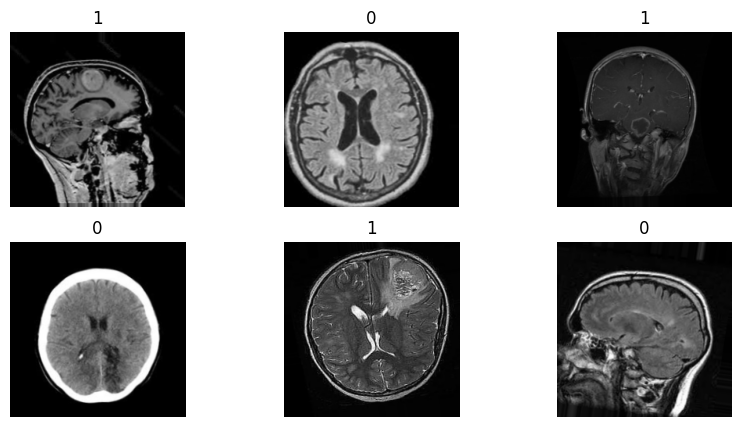

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(int(labels[i]))
    plt.axis('off')
plt.show()

day 4-Baseline Model

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten + Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(1, activation='sigmoid')   # binary classification
])

model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_gen)

print(f"\n✅ Baseline Test Accuracy: {test_accuracy:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Baseline Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.save("model_baseline.h5")
print("Model saved successfully!")

day 5: Advanced Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_mobilenet = models.Model(inputs=base_model.input, outputs=output)


model_mobilenet.summary()

model_mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train
history_mob = model_mobilenet.fit(train_gen, validation_data=val_gen, epochs=5)

In [ ]:
# Fine-tune
for layer in base_model.layers[-30:]:
    layer.trainable = True

model_mobilenet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

history_mob_fine = model_mobilenet.fit(train_gen, validation_data=val_gen, epochs=5)

# Evaluate
mob_loss, mob_acc = model_mobilenet.evaluate(test_gen)
print("MobileNet Accuracy:", mob_acc)

model_mobilenet.save("model_mobilenet.h5")

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_resnet = models.Model(inputs=base_model.input, outputs=output)

model_resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_res = model_resnet.fit(train_gen, validation_data=val_gen, epochs=5)

In [ ]:

# Fine-tune
for layer in base_model.layers[-40:]:
    layer.trainable = True

model_resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

history_res_fine = model_resnet.fit(train_gen, validation_data=val_gen, epochs=5)

# Evaluate
res_loss, res_acc = model_resnet.evaluate(test_gen)
print("ResNet Accuracy:", res_acc)

model_resnet.save("model_resnet.h5")

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Head
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_vgg = model_vgg.fit(train_gen, validation_data=val_gen, epochs=5)

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

# Head
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_vgg = model_vgg.fit(train_gen, validation_data=val_gen, epochs=5)


In [ ]:

# Fine-tune
for layer in base_model.layers[-20:]:
    layer.trainable = True

model_vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_vgg_fine = model_vgg.fit(train_gen, validation_data=val_gen, epochs=5)

# Evaluate
vgg_loss, vgg_acc = model_vgg.evaluate(test_gen)
print("VGG Accuracy:", vgg_acc)

model_vgg.save("model_vgg.h5")

In [ ]:
print("\n===== Model Comparison =====")
print(f"MobileNet Accuracy: {mob_acc:.4f}")
print(f"ResNet Accuracy:    {res_acc:.4f}")
print(f"VGG Accuracy:       {vgg_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "MobileNet", "ResNet", "VGG"]
accuracies = [cnn_acc, mob_acc, res_acc, vgg_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
cnn_loss, cnn_acc = model.evaluate(test_gen)
print("CNN Accuracy:", cnn_acc)

In [ ]:
cnn_loss, cnn_acc = model.evaluate(test_gen)
print("CNN Accuracy:", cnn_acc)

In [ ]:
print("\n===== Model Comparison =====")

print(f"CNN (Baseline) Accuracy: {cnn_acc:.4f}")
print(f"MobileNet Accuracy:      {mob_acc:.4f}")
print(f"ResNet Accuracy:         {res_acc:.4f}")
print(f"VGG Accuracy:            {vgg_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "MobileNet", "ResNet", "VGG"]
losses = [cnn_loss, mob_loss, res_loss, vgg_loss]

plt.figure(figsize=(8,5))
plt.bar(models, losses)

plt.title("Model Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")

# Show values on top
for i, v in enumerate(losses):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

Day 6 – Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Predictions
y_pred_cnn = (model.predict(test_gen) > 0.5).astype("int32")
y_pred_mob = (model_mobilenet.predict(test_gen) > 0.5).astype("int32")
y_pred_res = (model_resnet.predict(test_gen) > 0.5).astype("int32")
y_pred_vgg = (model_vgg.predict(test_gen) > 0.5).astype("int32")

# True labels
y_true = y_test

In [ ]:
print("\n===== CNN =====")
print(classification_report(y_true, y_pred_cnn))

print("\n===== MobileNet =====")
print(classification_report(y_true, y_pred_mob))

print("\n===== ResNet =====")
print(classification_report(y_true, y_pred_res))

print("\n===== VGG =====")
print(classification_report(y_true, y_pred_vgg))

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
plot_cm(y_true, y_pred_cnn, "CNN Confusion Matrix")
plot_cm(y_true, y_pred_mob, "MobileNet Confusion Matrix")
plot_cm(y_true, y_pred_res, "ResNet Confusion Matrix")
plot_cm(y_true, y_pred_vgg, "VGG Confusion Matrix")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

results = {
    "CNN": get_metrics(y_true, y_pred_cnn),
    "MobileNet": get_metrics(y_true, y_pred_mob),
    "ResNet": get_metrics(y_true, y_pred_res),
    "VGG": get_metrics(y_true, y_pred_vgg)
}

print("\n===== Final Metrics Comparison =====")
for model, metrics in results.items():
    print(f"{model}: Accuracy={metrics[0]:.4f}, Precision={metrics[1]:.4f}, Recall={metrics[2]:.4f}, F1={metrics[3]:.4f}")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [ ]:
import matplotlib.pyplot as plt

# Store results
models = ["CNN", "MobileNet", "ResNet", "VGG"]
accuracies = [cnn_acc, mob_acc, res_acc, vgg_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
import numpy as np

labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

cnn_metrics = get_metrics(y_true, y_pred_cnn)
mob_metrics = get_metrics(y_true, y_pred_mob)
res_metrics = get_metrics(y_true, y_pred_res)
vgg_metrics = get_metrics(y_true, y_pred_vgg)

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, cnn_metrics, width, label="CNN")
plt.bar(x - 0.5*width, mob_metrics, width, label="MobileNet")
plt.bar(x + 0.5*width, res_metrics, width, label="ResNet")
plt.bar(x + 1.5*width, vgg_metrics, width, label="VGG")

plt.xticks(x, labels)
plt.title("Model Comparison (All Metrics)")
plt.ylabel("Score")
plt.legend()

plt.show()

In [ ]:
best_model = max(
    {"CNN": cnn_acc, "MobileNet": mob_acc, "ResNet": res_acc, "VGG": vgg_acc},
    key=lambda x: {"CNN": cnn_acc, "MobileNet": mob_acc, "ResNet": res_acc, "VGG": vgg_acc}[x]
)

print("Best Model:", best_model)

In [31]:
from tensorflow.keras import layers, models
import tensorflow as tf

model_cnn_best = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model_cnn_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn_best = model_cnn_best.fit(train_gen, validation_data=val_gen, epochs=10)

cnn_best_loss, cnn_best_acc = model_cnn_best.evaluate(test_gen)
print("Improved CNN Accuracy:", cnn_best_acc)

model_cnn_best.save("best_cnn.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 65s 519ms/step - accuracy: 0.6419 - loss: 1.6369 - val_accuracy: 0.5464 - val_loss: 8.3510
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 375ms/step - accuracy: 0.7289 - loss: 0.5297 - val_accuracy: 0.5464 - val_loss: 12.2731
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 390ms/step - accuracy: 0.7736 - loss: 0.4642 - val_accuracy: 0.6348 - val_loss: 1.7630
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 377ms/step - accuracy: 0.7845 - loss: 0.4204 - val_accuracy: 0.7043 - val_loss: 0.8236
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 374ms/step - accuracy: 0.8062 - loss: 0.3794 - val_accuracy: 0.7536 - val_loss: 0.8027
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 375ms/step - accuracy: 0.8065 - loss: 0.3771 - val_accuracy: 0.7072 - val_loss: 0.7116
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 375ms/step - accuracy: 0.8276 - loss: 0.3532 - val_accuracy: 0.7667 - val_loss: 0.5557
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 377ms/step - accuracy: 0.8354 - loss: 

Improved CNN Accuracy: 0.8478260636329651


In [32]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_mob_best = models.Model(inputs=base_model.input, outputs=output)

model_mob_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mob_best.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune more layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

model_mob_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mob_best.fit(train_gen, validation_data=val_gen, epochs=5)

mob_best_loss, mob_best_acc = model_mob_best.evaluate(test_gen)
print("Improved MobileNet Accuracy:", mob_best_acc)

model_mob_best.save("best_mobilenet.h5")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 485ms/step - accuracy: 0.8189 - loss: 0.4051 - val_accuracy: 0.8696 - val_loss: 0.3015
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 371ms/step - accuracy: 0.9093 - loss: 0.2315 - val_accuracy: 0.9246 - val_loss: 0.2017
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 358ms/step - accuracy: 0.9301 - loss: 0.1827 - val_accuracy: 0.9203 - val_loss: 0.1781
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 350ms/step - accuracy: 0.9413 - loss: 0.1484 - val_accuracy: 0.9406 - val_loss: 0.1583
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 363ms/step - accuracy: 0.9540 - loss: 0.1315 - val_accuracy: 0.9377 - val_loss: 0.1510
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 75s 519ms/step - accuracy: 0.8410 - loss: 0.3913 - val_accuracy: 0.9188 - val_loss: 0.1993
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 369ms/step - accuracy: 0.9140 - loss: 0.2261 - val_accuracy: 0.9145 - val_loss: 0.2214
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 37

Improved MobileNet Accuracy: 0.9405797123908997


In [33]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)
x = base_model.output
model_res_best = models.Model(inputs=base_model.input, outputs=output)

model_res_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_res_best.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-60:]:
    layer.trainable = True

model_res_best.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_res_best.fit(train_gen, validation_data=val_gen, epochs=5)

res_best_loss, res_best_acc = model_res_best.evaluate(test_gen)
print("Improved ResNet Accuracy:", res_best_acc)

model_res_best.save("best_resnet.h5")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 70s 541ms/step - accuracy: 0.7242 - loss: 0.5592 - val_accuracy: 0.7043 - val_loss: 0.6421
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 399ms/step - accuracy: 0.7671 - loss: 0.4998 - val_accuracy: 0.7014 - val_loss: 0.6088
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 400ms/step - accuracy: 0.7879 - loss: 0.4565 - val_accuracy: 0.7522 - val_loss: 0.5494
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 399ms/step - accuracy: 0.7966 - loss: 0.4393 - val_accuracy: 0.7522 - val_loss: 0.5232
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 399ms/step - accuracy: 0.8016 - loss: 0.4233 - val_accuracy: 0.7841 - val_loss: 0.4588
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 93s 615ms/step - accuracy: 0.7062 - loss: 0.6917 - val_accuracy: 0.5290 - val_loss: 1.2331
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 44s 433ms/step - accuracy: 0.7714 - loss: 0.5220 - val_accuracy: 0.6812 - val_loss: 0.6610
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 

Improved ResNet Accuracy: 0.8681159615516663


In [34]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.Flatten()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)


model_vgg_best = models.Model(inputs=base_model.input, outputs=output)

model_vgg_best.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg_best.fit(train_gen, validation_data=val_gen, epochs=5)

# Fine-tune
for layer in base_model.layers[-25:]:
    layer.trainable = True

model_vgg_best.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg_best.fit(train_gen, validation_data=val_gen, epochs=5)

vgg_best_loss, vgg_best_acc = model_vgg_best.evaluate(test_gen)
print("Improved VGG Accuracy:", vgg_best_acc)

model_vgg_best.save("best_vgg.h5")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 88s 707ms/step - accuracy: 0.8488 - loss: 0.4637 - val_accuracy: 0.7957 - val_loss: 0.4388
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 480ms/step - accuracy: 0.9239 - loss: 0.2569 - val_accuracy: 0.9406 - val_loss: 0.1602
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 474ms/step - accuracy: 0.9460 - loss: 0.1839 - val_accuracy: 0.9652 - val_loss: 0.1047
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 482ms/step - accuracy: 0.9630 - loss: 0.1371 - val_accuracy: 0.9681 - val_loss: 0.0835
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 485ms/step - accuracy: 0.9640 - loss: 0.1188 - val_accuracy: 0.9783 - val_loss: 0.0776
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 148s 980ms/step - accuracy: 0.9693 - loss: 0.0955 - val_accuracy: 0.9783 - val_loss: 0.0935
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 65s 642ms/step - accuracy: 0.9776 - loss: 0.0679 - val_accuracy: 0.9812 - val_loss: 0.0797
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━

Improved VGG Accuracy: 0.9681159257888794


In [35]:
results = {
    "CNN": cnn_best_acc,
    "MobileNet": mob_best_acc,
    "ResNet": res_best_acc,
    "VGG": vgg_best_acc
}

best_model = max(results, key=results.get)

print("\n===== BEST MODEL =====")
print(best_model, ":", results[best_model])


===== BEST MODEL =====
VGG : 0.9681159257888794


In [37]:
results = {
    "CNN": cnn_best_acc,
    "MobileNet": mob_best_acc,
    "ResNet": res_best_acc,
    "VGG": vgg_best_acc
}

best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: VGG


In [38]:
if best_model_name == "CNN":
    best_model = model_cnn_best
elif best_model_name == "MobileNet":
    best_model = model_mobilenet
elif best_model_name == "ResNet":
    best_model = model_resnet
else:
    best_model = model_vgg_best

best_model.save("best_model.keras")

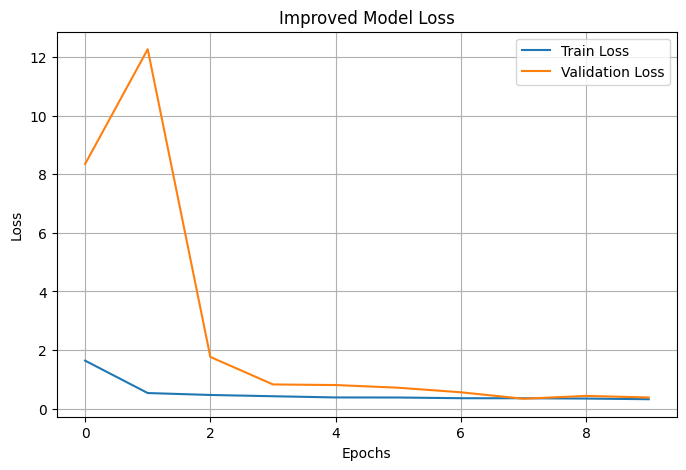

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_cnn_best.history['loss'], label='Train Loss')
plt.plot(history_cnn_best.history['val_loss'], label='Validation Loss')

plt.title("Improved Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

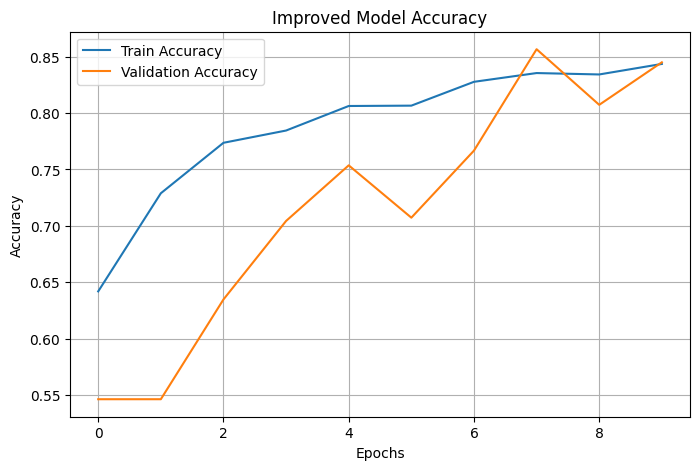

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_cnn_best.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_best.history['val_accuracy'], label='Validation Accuracy')

plt.title("Improved Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [42]:
model_cnn_best.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,509,061 (127.83 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 22,339,076 (85.22 MB)

In [43]:
model_vgg_best.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25088)          │       100,352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 63,613,893 (242.67 MB)

 Trainable params: 21,187,905 (80.83 MB)

 Non-trainable params: 50,176 (196.00 KB)

 Optimizer params: 42,375,812 (161.65 MB)

In [46]:
model_mob_best.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 6,470,725 (24.68 MB)

 Trainable params: 2,021,761 (7.71 MB)

 Non-trainable params: 405,440 (1.55 MB)

 Optimizer params: 4,043,524 (15.42 MB)

In [47]:
best_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25088)          │       100,352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 63,613,893 (242.67 MB)

 Trainable params: 21,187,905 (80.83 MB)

 Non-trainable params: 50,176 (196.00 KB)

 Optimizer params: 42,375,812 (161.65 MB)

In [48]:
best_model.summary(line_length=120)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_layer_3 (InputLayer)                          │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block1_conv1 (Conv2D)                               │ (None, 224, 224, 64)                   │                 1,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block1_conv2 (Conv2D)                               │ (None, 224, 224, 64)                   │                36,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block1_pool (MaxPooling2D)                          │ (None, 112, 112, 64)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block2_conv1 (Conv2D)                               │ (None, 112, 112, 128)                  │                73,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block2_conv2 (Conv2D)                               │ (None, 112, 112, 128)                  │               147,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block2_pool (MaxPooling2D)                          │ (None, 56, 56, 128)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block3_conv1 (Conv2D)                               │ (None, 56, 56, 256)                    │               295,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block3_conv2 (Conv2D)                               │ (None, 56, 56, 256)                    │               590,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block3_conv3 (Conv2D)                               │ (None, 56, 56, 256)                    │               590,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block3_pool (MaxPooling2D)                          │ (None, 28, 28, 256)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block4_conv1 (Conv2D)                               │ (None, 28, 28, 512)                    │             1,180,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block4_conv2 (Conv2D)                               │ (None, 28, 28, 512)                    │             2,359,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block4_conv3 (Conv2D)                               │ (None, 28, 28, 512)                    │             2,359,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block4_pool (MaxPooling2D)                          │ (None, 14, 14, 512)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ block5_conv1 (Conv2D)                               │ (None, 14, 14, 512)                    │             2,359,
├─────────────────────────────────────────────────────┼─

 Total params: 63,613,893 (242.67 MB)

 Trainable params: 21,187,905 (80.83 MB)

 Non-trainable params: 50,176 (196.00 KB)

 Optimizer params: 42,375,812 (161.65 MB)